In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-04

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Statistical Distributions — Toolbox Vignette (_r2p)
====================================================

Purpose:
    Reference card for statistical distributions using Python's scipy.stats.
    Covers the full d/p/q/r function family from R, mapped to scipy equivalents.

    Distributions covered:
      - Normal distribution: PDF, CDF (pnorm), quantile (qnorm)
      - t-distribution:      PDF, CDF (pt),    quantile (qt)
      - Q-Q plots (qqnorm + qqline)
      - Shapiro-Wilk normality test
      - 2x2 histogram panel: Normal, Uniform, Exponential, t

    R d/p/q/r → scipy.stats mapping:
      dnorm(z)        → norm.pdf(z)
      pnorm(x)        → norm.cdf(x)
      qnorm(p)        → norm.ppf(p)
      rnorm(n)        → rng.normal(n)
      dt(t, df)       → t_dist.pdf(t, df)
      pt(x, df)       → t_dist.cdf(x, df)
      qt(p, df)       → t_dist.ppf(p, df)
      rt(n, df)       → rng.standard_t(df, n)
      runif(n)        → rng.uniform(n)
      rexp(n)         → rng.exponential(n)
      shapiro.test(x) → scipy.stats.shapiro(x)

    Reference: Dr. Bharatendra Rai YouTube channel (cited in original R script).

    R equivalent: stat_distributions_vignette.Rmd
    R libraries:  DAAG, dplyr, base R
    Python libs:  numpy, pandas, matplotlib, seaborn, scipy.stats, statsmodels

    Suffix _r2p: This notebook was converted from R to Python.

Revision History:
    2023-01-01  Original R development
                - R script: stat_distributions_vignette.Rmd
                - Reference: Dr. Bharatendra Rai YouTube channel

    2026-04-04  Converted to Python / Jupyter Notebook (_r2p)
                - R d/p/q/r functions → scipy.stats PDF/CDF/PPF/RVS
                - pretty(c(-5,5), 100) → np.linspace(-5, 5, 100)
                - plot(z, ht, type='l') → ax.plot(z, ht)
                - par(mfrow=c(2,2)) → plt.subplots(2, 2)
                - Added: full distribution reference table
                - Added: overlay comparison of all four distributions
"""

"\nCreated on 2023-01-01\nRevised on 2026-04-04\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nStatistical Distributions — Toolbox Vignette (_r2p)\n====================================================\n\nPurpose:\n    Reference card for statistical distributions using Python's scipy.stats.\n    Covers the full d/p/q/r function family from R, mapped to scipy equivalents.\n\n    Distributions covered:\n      - Normal distribution: PDF, CDF (pnorm), quantile (qnorm)\n      - t-distribution:      PDF, CDF (pt),    quantile (qt)\n      - Q-Q plots (qqnorm + qqline)\n      - Shapiro-Wilk normality test\n      - 2x2 histogram panel: Normal, Uniform, Exponential, t\n\n    R d/p/q/r → scipy.stats mapping:\n      dnorm(z)        → norm.pdf(z)\n      pnorm(x)        → norm.cdf(x)\n      qnorm(p)       

# Statistical Distributions — Toolbox Vignette

## Purpose

Reference card for statistical distributions using Python's `scipy.stats`.
Covers the full **d/p/q/r function family** from R, mapped to scipy equivalents.

| R function | Role | scipy.stats equivalent |
|-----------|------|------------------------|
| `dnorm(z)` | PDF — density at z | `norm.pdf(z)` |
| `pnorm(x)` | CDF — P(Z < x) | `norm.cdf(x)` |
| `qnorm(p)` | Quantile — z where P(Z<z)=p | `norm.ppf(p)` |
| `rnorm(n)` | Random sample | `rng.normal(size=n)` |
| `dt(t, df)` | t PDF | `t.pdf(x, df)` |
| `pt(x, df)` | t CDF | `t.cdf(x, df)` |
| `qt(p, df)` | t quantile | `t.ppf(p, df)` |
| `rt(n, df)` | t random sample | `rng.standard_t(df, size=n)` |
| `runif(n)` | Uniform random | `rng.uniform(size=n)` |
| `rexp(n)` | Exponential random | `rng.exponential(size=n)` |
| `shapiro.test(x)` | Shapiro-Wilk normality test | `scipy.stats.shapiro(x)` |

**Reference:** Dr. Bharatendra Rai YouTube channel (cited in original R script).

**R equivalent:** `stat_distributions_vignette.Rmd`

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t as t_dist

sns.set_theme(style='whitegrid')

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'

rng = np.random.default_rng(seed=42)

print('Imports complete.')

Imports complete.


---

# Normal Distribution

## Generate and Plot the PDF

Mirrors R:
```r
z  <- pretty(c(-5, 5), 100)   # 100 evenly spaced points
ht <- dnorm(z)                 # PDF values
plot(z, ht, type='l')          # line plot
```

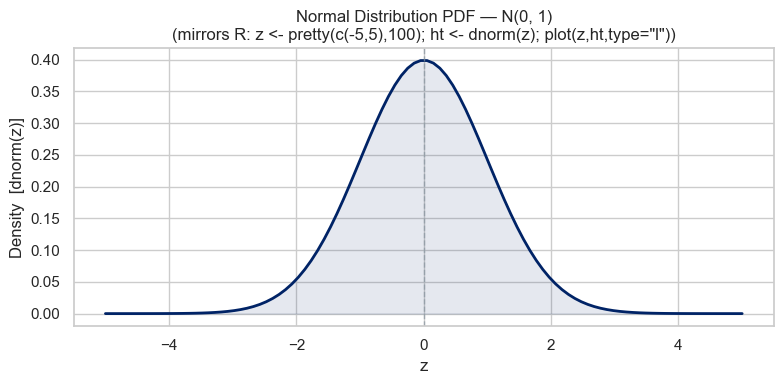

In [3]:
# Generate z values — mirrors R: pretty(c(-5, 5), 100)
z  = np.linspace(-5, 5, 100)

# PDF values — mirrors R: dnorm(z)
ht = norm.pdf(z)

# Plot — mirrors R: plot(z, ht, type='l')
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, ht, color=ROYALBLUE, linewidth=2)
ax.fill_between(z, ht, alpha=0.1, color=ROYALBLUE)
ax.axvline(0, color=SLATE, linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('z')
ax.set_ylabel('Density  [dnorm(z)]')
ax.set_title('Normal Distribution PDF — N(0, 1)\n'
             '(mirrors R: z <- pretty(c(-5,5),100); ht <- dnorm(z); plot(z,ht,type="l"))')
plt.tight_layout()
plt.show()

## CDF — P(Z < x)

Mirrors R: `pnorm(-2)` → P(Z < −2)

In [4]:
# P(Z < -2) — mirrors R: pnorm(-2)
p_z_less_minus2 = norm.cdf(-2)
print(f'P(Z < -2) = {p_z_less_minus2:.6f}   [mirrors R: pnorm(-2)]')
print(f'Interpretation: About {p_z_less_minus2*100:.2f}% of N(0,1) values fall below -2')

P(Z < -2) = 0.022750   [mirrors R: pnorm(-2)]
Interpretation: About 2.28% of N(0,1) values fall below -2


## Quantile — P(Z < ?) = 0.95

Mirrors R:
```r
qnorm(.95)          # standard Normal
qnorm(.95, 2, 0.5)  # N(mean=2, sd=0.5)
```

In [5]:
# 95th percentile of N(0,1) — mirrors R: qnorm(.95)
q95_std = norm.ppf(0.95)
print(f'qnorm(0.95)          = {q95_std:.6f}   [mirrors R: qnorm(.95)]')
print(f'  P(Z < {q95_std:.4f}) = 0.95 for N(0,1)')
print()

# 95th percentile of N(mean=2, sd=0.5) — mirrors R: qnorm(.95, 2, 0.5)
q95_shifted = norm.ppf(0.95, loc=2, scale=0.5)
print(f'qnorm(0.95, mean=2, sd=0.5) = {q95_shifted:.6f}   [mirrors R: qnorm(.95, 2, 0.5)]')
print(f'  P(Z < {q95_shifted:.4f}) = 0.95 for N(mean=2, sd=0.5)')

qnorm(0.95)          = 1.644854   [mirrors R: qnorm(.95)]
  P(Z < 1.6449) = 0.95 for N(0,1)

qnorm(0.95, mean=2, sd=0.5) = 2.822427   [mirrors R: qnorm(.95, 2, 0.5)]
  P(Z < 2.8224) = 0.95 for N(mean=2, sd=0.5)


## Normal PDF, CDF, and Quantile — Visual Summary

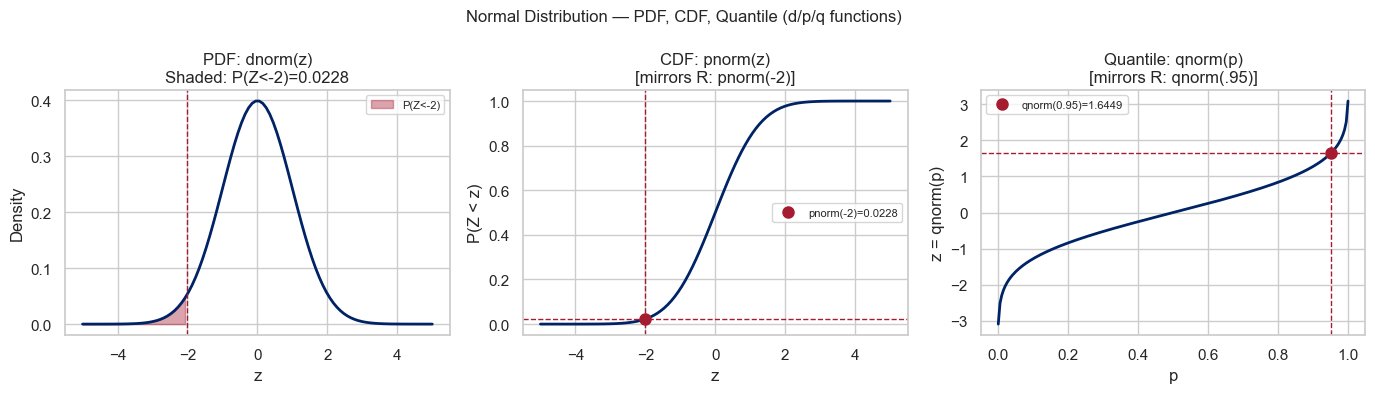

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# PDF
axes[0].plot(z, norm.pdf(z), color=ROYALBLUE, linewidth=2)
axes[0].fill_between(z[z <= -2], norm.pdf(z[z <= -2]),
                     alpha=0.4, color=CRIMSON, label=r'P(Z<-2)')
axes[0].axvline(-2, color=CRIMSON, linestyle='--', linewidth=1)
axes[0].set_title(f'PDF: dnorm(z)\nShaded: P(Z<-2)={norm.cdf(-2):.4f}')
axes[0].set_xlabel('z'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# CDF
axes[1].plot(z, norm.cdf(z), color=ROYALBLUE, linewidth=2)
axes[1].axvline(-2, color=CRIMSON, linestyle='--', linewidth=1)
axes[1].axhline(norm.cdf(-2), color=CRIMSON, linestyle='--', linewidth=1)
axes[1].plot(-2, norm.cdf(-2), 'o', color=CRIMSON, markersize=8,
             label=f'pnorm(-2)={norm.cdf(-2):.4f}')
axes[1].set_title('CDF: pnorm(z)\n[mirrors R: pnorm(-2)]')
axes[1].set_xlabel('z'); axes[1].set_ylabel('P(Z < z)')
axes[1].legend(fontsize=8)

# Quantile (PPF)
p_vals = np.linspace(0.001, 0.999, 200)
axes[2].plot(p_vals, norm.ppf(p_vals), color=ROYALBLUE, linewidth=2)
axes[2].axhline(norm.ppf(0.95), color=CRIMSON, linestyle='--', linewidth=1)
axes[2].axvline(0.95, color=CRIMSON, linestyle='--', linewidth=1)
axes[2].plot(0.95, norm.ppf(0.95), 'o', color=CRIMSON, markersize=8,
             label=f'qnorm(0.95)={norm.ppf(0.95):.4f}')
axes[2].set_title('Quantile: qnorm(p)\n[mirrors R: qnorm(.95)]')
axes[2].set_xlabel('p'); axes[2].set_ylabel('z = qnorm(p)')
axes[2].legend(fontsize=8)

fig.suptitle('Normal Distribution — PDF, CDF, Quantile (d/p/q functions)',
             fontsize=12)
plt.tight_layout()
plt.show()

---

# t-Distribution

## Generate and Plot the PDF

Mirrors R:
```r
t  <- pretty(c(-5, 5), 100)
ht <- dt(t, 3)                 # t PDF with 3 degrees of freedom
plot(t, ht, type='l')
```

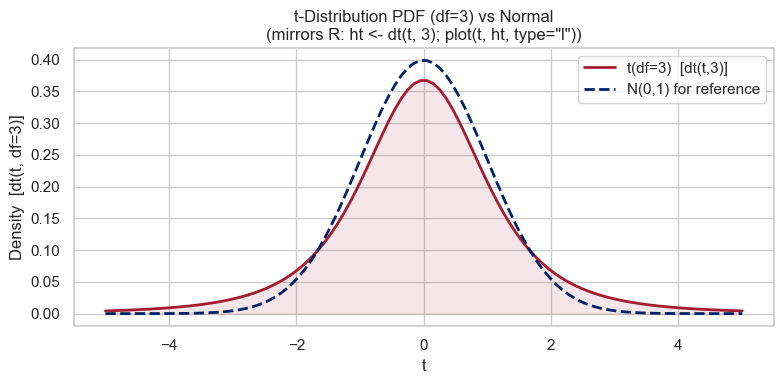

Note: t(df=3) has heavier tails than N(0,1).
As df → ∞, t-distribution → Normal.


In [7]:
# t values — mirrors R: t <- pretty(c(-5, 5), 100)
t_vals = np.linspace(-5, 5, 100)

# PDF — mirrors R: dt(t, 3)
ht_t = t_dist.pdf(t_vals, df=3)

# Plot with Normal overlay for comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_vals, ht_t,          color=CRIMSON,   linewidth=2,
        label='t(df=3)  [dt(t,3)]')
ax.plot(t_vals, norm.pdf(t_vals), color=ROYALBLUE, linewidth=2,
        linestyle='--', label='N(0,1) for reference')
ax.fill_between(t_vals, ht_t, alpha=0.1, color=CRIMSON)
ax.set_xlabel('t')
ax.set_ylabel('Density  [dt(t, df=3)]')
ax.set_title('t-Distribution PDF (df=3) vs Normal\n'
             '(mirrors R: ht <- dt(t, 3); plot(t, ht, type="l"))')
ax.legend()
plt.tight_layout()
plt.show()

print('Note: t(df=3) has heavier tails than N(0,1).')
print('As df → ∞, t-distribution → Normal.')

## CDF and Quantile — t-distribution

Mirrors R:
```r
pt(-2, 3)    # P(t < -2) with df=3
qt(.95, 3)   # 95th percentile with df=3
```

In [8]:
# P(t < -2) with df=3 — mirrors R: pt(-2, 3)
p_t_less_minus2 = t_dist.cdf(-2, df=3)
print(f'pt(-2, df=3)  = {p_t_less_minus2:.6f}   [mirrors R: pt(-2, 3)]')
print(f'pnorm(-2)     = {norm.cdf(-2):.6f}   (Normal for comparison)')
print(f'  t has heavier tails → more probability in the extremes')
print()

# 95th percentile with df=3 — mirrors R: qt(.95, 3)
q95_t3 = t_dist.ppf(0.95, df=3)
print(f'qt(0.95, df=3) = {q95_t3:.6f}   [mirrors R: qt(.95, 3)]')
print(f'qnorm(0.95)    = {norm.ppf(0.95):.6f}   (Normal for comparison)')
print(f'  t(df=3) 95th percentile is wider than Normal — reflects heavier tails')

pt(-2, df=3)  = 0.069663   [mirrors R: pt(-2, 3)]
pnorm(-2)     = 0.022750   (Normal for comparison)
  t has heavier tails → more probability in the extremes

qt(0.95, df=3) = 2.353363   [mirrors R: qt(.95, 3)]
qnorm(0.95)    = 1.644854   (Normal for comparison)
  t(df=3) 95th percentile is wider than Normal — reflects heavier tails


---

# Q-Q Plots (Normal)

## Default Q-Q Plot

Mirrors R:
```r
x <- rnorm(10)
qqnorm(x)
qqline(x)
```

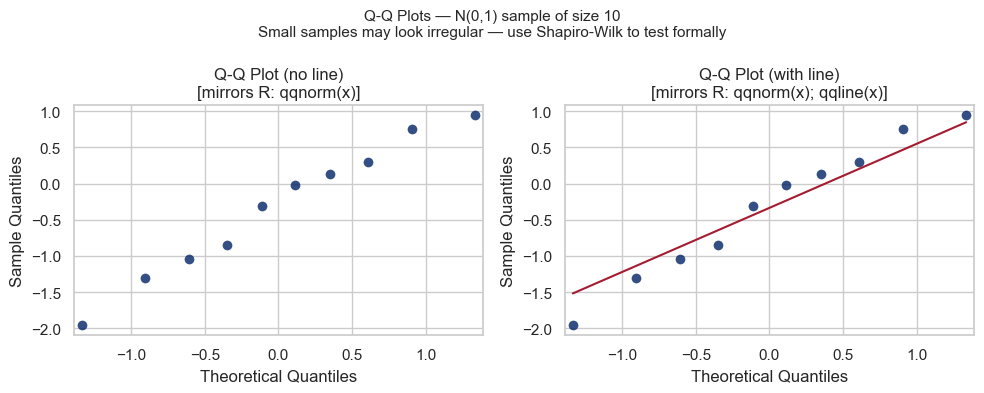

Note: With n=10 the result is subjective — Q-Q plot alone is insufficient.
Use Shapiro-Wilk for a formal test.


In [9]:
# Small sample — mirrors R: x <- rnorm(10)
x = rng.normal(0, 1, 10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Without line — mirrors R: qqnorm(x)
sm.qqplot(x, ax=axes[0],
          marker='o', markerfacecolor=ROYALBLUE,
          markeredgecolor='none', markersize=7, alpha=0.8)
axes[0].set_title('Q-Q Plot (no line)\n[mirrors R: qqnorm(x)]')

# With line — mirrors R: qqnorm(x); qqline(x)
sm.qqplot(x, line='s', ax=axes[1],
          marker='o', markerfacecolor=ROYALBLUE,
          markeredgecolor='none', markersize=7, alpha=0.8)
for line in axes[1].get_lines():
    line.set_color(CRIMSON); line.set_linewidth(1.5)
axes[1].set_title('Q-Q Plot (with line)\n[mirrors R: qqnorm(x); qqline(x)]')

fig.suptitle(f'Q-Q Plots — N(0,1) sample of size 10\n'
             f'Small samples may look irregular — use Shapiro-Wilk to test formally',
             fontsize=11)
plt.tight_layout()
plt.show()

print('Note: With n=10 the result is subjective — Q-Q plot alone is insufficient.')
print('Use Shapiro-Wilk for a formal test.')

---

# Simulations: Normal, Uniform, Exponential, t

Mirrors R:
```r
n <- rnorm(1000)
u <- runif(1000)
e <- rexp(1000)
t <- rt(1000, 3)
par(mfrow=c(2,2))
hist(n); hist(u); hist(e); hist(t)
```

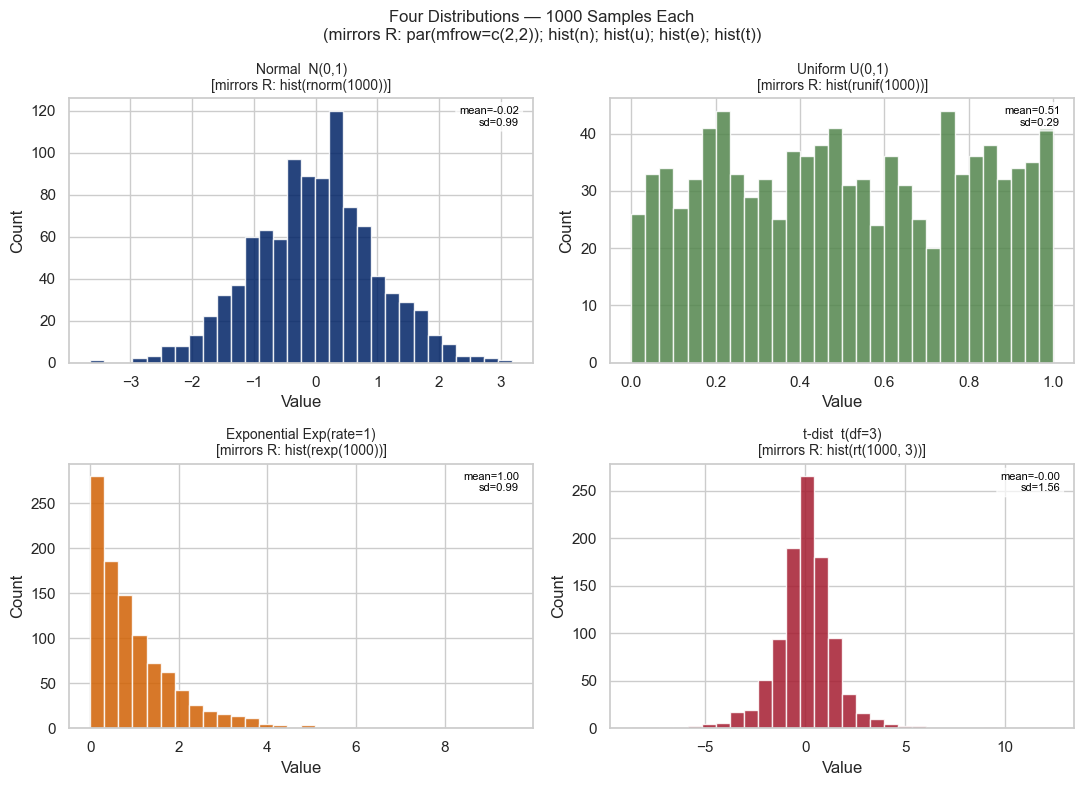

In [10]:
# Generate 1000 samples from each — mirrors R
n_samp = rng.normal(0, 1, 1000)          # rnorm(1000)
u_samp = rng.uniform(0, 1, 1000)         # runif(1000)
e_samp = rng.exponential(1, 1000)        # rexp(1000)
t_samp = rng.standard_t(df=3, size=1000) # rt(1000, 3)

# 2×2 histogram panel — mirrors R: par(mfrow=c(2,2)); hist(...)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

plot_data = [
    (n_samp, ROYALBLUE, 'Normal  N(0,1)',         'rnorm(1000)'),
    (u_samp, IVY,       'Uniform U(0,1)',          'runif(1000)'),
    (e_samp, SAFFRON,   'Exponential Exp(rate=1)', 'rexp(1000)'),
    (t_samp, CRIMSON,   't-dist  t(df=3)',         'rt(1000, 3)'),
]

for ax, (data, color, label, r_call) in zip(axes.flatten(), plot_data):
    ax.hist(data, bins=30, color=color, alpha=0.85,
            edgecolor='white')
    ax.set_title(f'{label}\n[mirrors R: hist({r_call})]', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.text(0.97, 0.97, f'mean={data.mean():.2f}\nsd={data.std():.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='black',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

fig.suptitle('Four Distributions — 1000 Samples Each\n'
             '(mirrors R: par(mfrow=c(2,2)); hist(n); hist(u); hist(e); hist(t))',
             fontsize=12)
plt.tight_layout()
plt.show()

---

# Normality Tests

## Q-Q Plot + Shapiro-Wilk

Mirrors R:
```r
x <- rnorm(10)
qqnorm(x); qqline(x)
shapiro.test(x)
```

> *"The result is subjective. This is a small dataset. So how do we know if this is Normal?"*
> — Original R vignette

**Answer:** Use the Shapiro-Wilk test.
- p-value > 0.05 → distribution is NOT significantly different from Normal → keep $H_0$
- p-value < 0.05 → reject $H_0$

NameError: name 'SHADE' is not defined

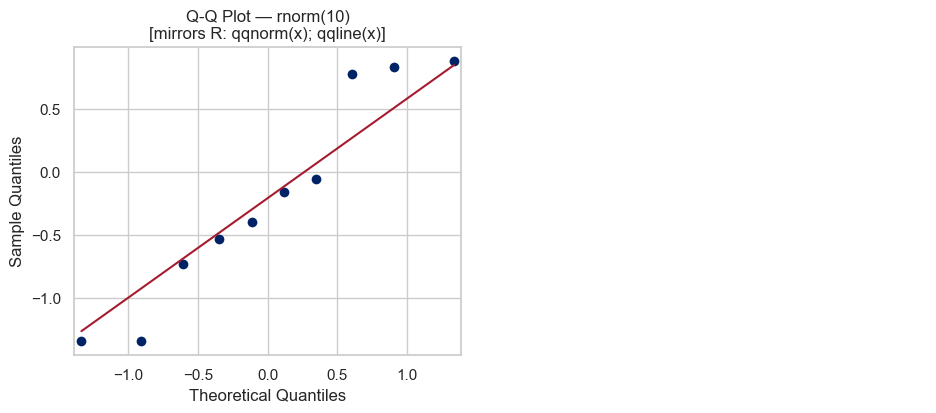

In [11]:
# Small sample — mirrors R: x <- rnorm(10)
x_norm = rng.normal(0, 1, 10)

# Q-Q plot — mirrors R: qqnorm(x); qqline(x)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sm.qqplot(x_norm, line='s', ax=axes[0],
          marker='o', markerfacecolor=ROYALBLUE,
          markeredgecolor='none', markersize=7)
for line in axes[0].get_lines():
    line.set_color(CRIMSON); line.set_linewidth(1.5)
axes[0].set_title('Q-Q Plot — rnorm(10)\n[mirrors R: qqnorm(x); qqline(x)]')

# Shapiro-Wilk — mirrors R: shapiro.test(x)
sw_stat, sw_p = stats.shapiro(x_norm)
decision = r'Keep $H_0$: plausibly Normal' if sw_p > 0.05 else r'Reject $H_0$: not Normal'
color    = IVY if sw_p > 0.05 else CRIMSON

# Display Shapiro result as text panel
axes[1].axis('off')
result_text = (
    f'Shapiro-Wilk Normality Test\n'
    f'[mirrors R: shapiro.test(x)]\n\n'
    f'  Statistic W = {sw_stat:.4f}\n'
    f'  p-value     = {sw_p:.4f}\n\n'
    f'  Threshold   : p > 0.05\n'
    f'  Decision    : {decision.replace("$", "")}\n\n'
    f'  H0: sample is from Normal distribution\n'
    f'  HA: sample is NOT from Normal distribution'
)
axes[1].text(0.05, 0.95, result_text, transform=axes[1].transAxes,
             fontsize=11, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor=SHADE if sw_p > 0.05 else '#FFE0E0',
                       alpha=0.5))
SHADE = '#BAC5C6'

fig.suptitle('Normality Test — Q-Q Plot and Shapiro-Wilk', fontsize=12)
plt.tight_layout()
plt.show()

# Mirrors R: shapiro.test(x) printed output
print('shapiro.test(x) output:')
print(f'  W = {sw_stat:.6f}')
print(f'  p-value = {sw_p:.6f}')
print()
print(f'  p-value > 0.05: {sw_p > 0.05}')
print(f'  Interpretation: {"NOT significantly different from Normal" if sw_p > 0.05 else "Significantly different from Normal"}')

---

## Overlay: All Four Distributions on One Plot

Not in the original R script — added as a Python extension.
Shows the shape differences between Normal, Uniform, Exponential, and t(df=3) at a glance.

In [ ]:
x_range = np.linspace(-5, 8, 300)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_range, norm.pdf(x_range),
        color=ROYALBLUE, linewidth=2, label='Normal N(0,1)  [dnorm]')
ax.plot(x_range, t_dist.pdf(x_range, df=3),
        color=CRIMSON,   linewidth=2, label='t(df=3)  [dt]',
        linestyle='--')
ax.plot(x_range, stats.expon.pdf(x_range),
        color=SAFFRON,   linewidth=2, label='Exponential(rate=1)  [dexp]',
        linestyle=':')
ax.plot([0, 1], [1, 1],
        color=IVY,       linewidth=2, label='Uniform U(0,1)  [dunif]',
        linestyle='-.')
ax.plot([0, 0], [0, 1],  color=IVY,  linewidth=2, linestyle='-.')
ax.plot([1, 1], [0, 1],  color=IVY,  linewidth=2, linestyle='-.')

ax.set_xlim(-5, 6)
ax.set_ylim(0, 0.55)
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('PDF Overlay — Normal, t(df=3), Exponential, Uniform\n'
             'Theoretical curves (d functions)')
ax.legend(fontsize=9)
ax.axhline(0, color=SLATE, linewidth=0.5)
plt.tight_layout()
plt.show()

---

# Summary

## R d/p/q/r → Python scipy.stats Full Reference

| R | Python | Description |
|---|--------|-------------|
| `dnorm(z)` | `norm.pdf(z)` | Normal PDF |
| `pnorm(x)` | `norm.cdf(x)` | Normal CDF: P(Z < x) |
| `qnorm(p)` | `norm.ppf(p)` | Normal quantile (inverse CDF) |
| `rnorm(n, mean, sd)` | `rng.normal(mean, sd, n)` | Normal random sample |
| `dt(t, df)` | `t_dist.pdf(x, df)` | t PDF |
| `pt(x, df)` | `t_dist.cdf(x, df)` | t CDF |
| `qt(p, df)` | `t_dist.ppf(p, df)` | t quantile |
| `rt(n, df)` | `rng.standard_t(df, n)` | t random sample |
| `runif(n, min, max)` | `rng.uniform(min, max, n)` | Uniform random sample |
| `dunif(x, min, max)` | `stats.uniform.pdf(x, min, max-min)` | Uniform PDF |
| `rexp(n, rate)` | `rng.exponential(1/rate, n)` | Exponential random sample |
| `dexp(x, rate)` | `stats.expon.pdf(x, scale=1/rate)` | Exponential PDF |
| `qqnorm(x)` | `sm.qqplot(x, ax=ax)` | Q-Q plot |
| `qqline(x)` | `sm.qqplot(x, line='s', ax=ax)` | Q-Q plot with reference line |
| `shapiro.test(x)` | `stats.shapiro(x)` → `(W, p)` | Shapiro-Wilk test |
| `pretty(c(-5,5), 100)` | `np.linspace(-5, 5, 100)` | Evenly spaced sequence |

## References

1. Dr. Bharatendra Rai. YouTube channel (cited in original R script).
   https://www.youtube.com/watch?v=rsfV57N7Uns
2. Harvard Elements of Statistical Learning (2021),
   Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
3. Gareth James, et al. *An Introduction to Statistical Learning
   with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
4. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com